# Rules & systems summary

Point this at a scenario config and it tells you what the world *is*: every
transform, what each resource costs to simply keep existing, which way goods
flow along tagged roads, where priority changes come from, and — after a replay
— which rules actually fire versus which are dead letters.

The centrepiece is an interactive flow DAG with two views over the same layout:

| view | nodes | reads as |
|---|---|---|
| **Transforms** | resources + transforms | exact Petri net — nothing is lost |
| **Resource flow** | resources only | flow diagram; responsible transforms live in the edge tooltip |

**Hover any edge or node.** Everything else dims and a panel names the
transform(s) responsible, the stoichiometry, the net effect, and how much
actually flowed. Hovering a transform lights up its whole recipe.

`analysis.py` derives the facts (pure, no rendering); `dagviz.py` emits
self-contained SVG. Neither touches `sim/`.

In [4]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # repo root, so `import sim` works

from IPython.display import Markdown, display

from sim import load_scenario, initial_world, run_turn, SpendNudges
import analysis
import dagviz
import viz

DATA = Path.cwd().parent / "scenarios_data"

# ring-valley exercises the whole design: tagged roads with counter-flow, a
# control terminal minting nudges, and a cultural movement that reorders a
# stack on its own. simple-world is the minimal reference (and still collapses
# — see issue #1).
CONFIG = DATA / "ring-valley.json"

## 1. Load the config

Raw JSON alongside the compiled `Scenario` — the compiler drops `description`,
and it is worth showing.

In [5]:
raw = json.loads(CONFIG.read_text())
scenario = load_scenario(CONFIG)

print(f"{scenario.name}: {scenario.R} resources, {scenario.T} transforms, "
      f"{scenario.L} locations")
print(f"evaluation order: {' -> '.join(raw['evaluation_order'])}")
print(f"edge tags: {', '.join(sorted(t for t in scenario.upstream_by_tag if t != 'nearby'))}")

ring-valley: 14 resources, 21 transforms, 3 locations
evaluation order: town -> farmstead -> forest
edge tags: cityward, forestward


## 2. Rules & systems

Read the **cheapest hold** column first — under universal decay it is the price of
merely continuing to exist, and it is where scenarios quietly go wrong. The
logistics and politics sections are derived from the config too: which tag moves
what, and which transforms can change a priority. Warnings at the bottom are
derived, not hand-written.

In [7]:
display(Markdown(analysis.rules_summary(scenario, raw.get("description", ""))))

## ring-valley

_Three settlements strung along a corridor. Every road is a symmetric pair of edges carrying opposite tags, so nothing moves unless a transport transform pulls it along a direction. Buildings are catalysts, which is what caps each job's throughput. The town mints nudges from a control terminal; the forest preaches a back-to-the-land movement that ships downstream and nudges the town's stack with no player involved._

**14 resources · 21 transforms · 3 locations**

### Transforms

| transform | recipe | draws from | kind | net effect | notes |
|---|---|---|---|---|---|
| `staff_control_terminal` | 1 person + 1 energy + 1 control_terminal → 1 person + 1 control_terminal + 1 nudge | `local` | conversion | -1 energy, +1 nudge | needs person, control_terminal present |
| `preach` | 1 person + 1 plant + 1 chapel → 1 person + 1 chapel + 1 back_to_the_land | `local` | conversion | -1 plant, +1 back_to_the_land | needs person, chapel present |
| `ship_movement_cityward` | 1 back_to_the_land → 1 back_to_the_land | `cityward` | free storage | none (pure hold) | needs back_to_the_land present |
| `agitate` | 2 person + 1 back_to_the_land → 2 person | `local` | upkeep | -1 back_to_the_land | nudges farming +1, nudges logging -1, needs person present |
| `haul_cityward` | 1 wood → 1 wood | `cityward` | free storage | none (pure hold) | needs wood present |
| `haul_food_forestward` | 1 food → 1 food | `forestward` | free storage | none (pure hold) | needs food present |
| `logging` | 1 person + 1 plant + 1 sawmill → 1 person + 1 wood + 1 sawmill | `local` | conversion | -1 plant, +1 wood | needs person, sawmill present |
| `farming` | 1 person + 1 plant + 1 energy + 1 field → 1 person + 2 food + 1 field | `local` | conversion | +2 food, -1 plant, -1 energy | needs person, field present |
| `growth` | 1 plant + 1 energy + 1 nursery → 2 plant + 1 nursery | `local` | conversion | +1 plant, -1 energy | amplifies plant ×2, needs nursery present |
| `survival` | 1 person + 1 food + 1 air → 1 person | `local` | upkeep | -1 food, -1 air | needs person present |
| `atmosphere` | 1 plant + 1 energy + 1 scrubber → 1 plant + 1 air + 1 scrubber | `local` | conversion | -1 energy, +1 air | needs plant, scrubber present |
| `food_storage` | 1 food + 1 energy → 1 food | `local` | upkeep | -1 energy | needs food present |
| `wood_storage` | 1 wood → 1 wood | `local` | free storage | none (pure hold) | needs wood present |
| `photosynthesis` | 1 plant → 1 plant + 1 energy | `local` | free production | +1 energy | needs plant present |
| `air_storage` | 1 air → 1 air | `local` | free storage | none (pure hold) | needs air present |
| `chapel_upkeep` | 1 chapel → 1 chapel | `local` | free storage | none (pure hold) | needs chapel present |
| `sawmill_upkeep` | 1 sawmill → 1 sawmill | `local` | free storage | none (pure hold) | needs sawmill present |
| `field_upkeep` | 1 field → 1 field | `local` | free storage | none (pure hold) | needs field present |
| `terminal_upkeep` | 1 control_terminal → 1 control_terminal | `local` | free storage | none (pure hold) | needs control_terminal present |
| `scrubber_upkeep` | 1 scrubber → 1 scrubber | `local` | free storage | none (pure hold) | needs scrubber present |
| `nursery_upkeep` | 1 nursery → 1 nursery | `local` | free storage | none (pure hold) | needs nursery present |

### Resources — persistence under universal decay

Nothing carries over on its own. A resource survives the turn only if a transform emits it, so the *cheapest hold* column is the actual cost of simply existing.

| resource | initial | emitted by | consumed by | cheapest hold | status |
|---|---|---|---|---|---|
| `person` | 13 | `staff_control_terminal`, `preach`, `agitate`, `logging`, `farming`, `survival` | `staff_control_terminal`, `preach`, `agitate`, `logging`, `farming`, `survival` | `agitate` (0.5 back_to_the_land per unit) | needs upkeep every turn |
| `food` | 26 | `haul_food_forestward`, `farming`, `food_storage` | `haul_food_forestward`, `survival`, `food_storage` | `haul_food_forestward` (free) | self-sustaining |
| `plant` | 88 | `growth`, `atmosphere`, `photosynthesis` | `preach`, `logging`, `farming`, `growth`, `atmosphere`, `photosynthesis` | `photosynthesis` (free) | self-sustaining |
| `energy` | 24 | `photosynthesis` | `staff_control_terminal`, `farming`, `growth`, `atmosphere`, `food_storage` | `photosynthesis` (free) | self-sustaining |
| `air` | 32 | `atmosphere`, `air_storage` | `survival`, `air_storage` | `air_storage` (free) | self-sustaining |
| `wood` | 0 | `haul_cityward`, `logging`, `wood_storage` | `haul_cityward`, `wood_storage` | `haul_cityward` (free) | self-sustaining |
| `scrubber` | 13 | `atmosphere`, `scrubber_upkeep` | `atmosphere`, `scrubber_upkeep` | `scrubber_upkeep` (free) | self-sustaining |
| `nursery` | 14 | `growth`, `nursery_upkeep` | `growth`, `nursery_upkeep` | `nursery_upkeep` (free) | self-sustaining |
| `chapel` | 1 | `preach`, `chapel_upkeep` | `preach`, `chapel_upkeep` | `chapel_upkeep` (free) | self-sustaining |
| `sawmill` | 2 | `logging`, `sawmill_upkeep` | `logging`, `sawmill_upkeep` | `sawmill_upkeep` (free) | self-sustaining |
| `field` | 5 | `farming`, `field_upkeep` | `farming`, `field_upkeep` | `field_upkeep` (free) | self-sustaining |
| `control_terminal` | 1 | `staff_control_terminal`, `terminal_upkeep` | `staff_control_terminal`, `terminal_upkeep` | `terminal_upkeep` (free) | self-sustaining |
| `nudge` | 0 | `staff_control_terminal` | — | `staff_control_terminal` (1 energy per unit) | needs upkeep every turn |
| `back_to_the_land` | 0 | `preach`, `ship_movement_cityward` | `ship_movement_cityward`, `agitate` | `ship_movement_cityward` (free) | self-sustaining |

### Systems

- **Free production:** `photosynthesis` — output with no net input. These are the only true sources; everything else is a redistribution.
- **Amplifiers:** `growth` grows plant ×2 — the only way the economy expands.
- **Loop:** chapel →[preach]→ person · person →[preach]→ chapel
- **Loop:** control_terminal →[staff_control_terminal]→ person · person →[staff_control_terminal]→ control_terminal
- **Loop:** energy →[growth/atmosphere]→ plant · plant →[photosynthesis]→ energy
- **Loop:** field →[farming]→ person · person →[farming]→ field
- **Loop:** food →[survival]→ person · person →[farming]→ food
- **Loop:** person →[preach]→ back_to_the_land · back_to_the_land →[agitate]→ person
- **Loop:** plant →[growth]→ nursery · nursery →[growth]→ plant
- **Loop:** plant →[atmosphere]→ scrubber · scrubber →[atmosphere]→ plant
- **Loop:** sawmill →[logging]→ person · person →[logging]→ sawmill
- **Loop:** chapel →[preach]→ back_to_the_land · back_to_the_land →[agitate]→ person · person →[preach]→ chapel
- **Loop:** energy →[growth]→ nursery · nursery →[growth]→ plant · plant →[photosynthesis]→ energy
- **Loop:** energy →[atmosphere]→ scrubber · scrubber →[atmosphere]→ plant · plant →[photosynthesis]→ energy

### Logistics — tagged edges

A road is a symmetric pair of edges, so topology alone carries no direction. Each tag filters the graph down to an acyclic direction field; a transform naming that tag pulls one hop along it per turn, and the reverse tag on the same roads carries counter-flow.

| tag | edges | transforms pulling along it |
|---|---|---|
| `cityward` | forest → farmstead · farmstead → town | `ship_movement_cityward` (back_to_the_land), `haul_cityward` (wood) |
| `forestward` | farmstead → forest · town → farmstead | `haul_food_forestward` (food) |

### Politics — where priority changes come from

- **Player capacity:** `staff_control_terminal` mints 1 nudge per firing, capped by person, control_terminal. Nudges are spent where they sit, one per point of priority moved, and decay unspent.
- **Autonomous:** `agitate` emits `farming` +1, `logging` -1 per firing, with no player involved. Deltas superpose with everything else and land after the pass that produced them.

### Locations

| location | eval # | initial stock | upstream (pool it may draw from) | feeds |
|---|---|---|---|---|
| `forest` | 2 | 4 person + 8 food + 40 plant + 8 energy + 10 air + 4 scrubber + 5 nursery + 1 chapel + 2 sawmill | `farmstead` | `farmstead` |
| `farmstead` | 1 | 4 person + 8 food + 24 plant + 8 energy + 10 air + 4 scrubber + 5 nursery + 3 field | `forest`, `town` | `forest`, `town` |
| `town` | 0 | 5 person + 10 food + 24 plant + 8 energy + 12 air + 5 scrubber + 4 nursery + 2 field + 1 control_terminal | `farmstead` | `farmstead` |

### Warnings

- `forest` feeds `farmstead`, but `farmstead` is evaluated first and draws from `forest`'s pool. `forest` may be empty by its own turn, making it a one-turn pass-through buffer rather than a producer.
- `farmstead` feeds `town`, but `town` is evaluated first and draws from `farmstead`'s pool. `farmstead` may be empty by its own turn, making it a one-turn pass-through buffer rather than a producer.


## 3. Replay

Run the engine forward and record what fired. This is what separates *rules that
exist* from *rules that matter* — and it drives the edge widths in the DAG below.

In [8]:
runtime = analysis.run_and_observe(scenario, ticks=20)
display(Markdown(analysis.observed_summary(scenario, runtime)))

## Observed over 20 ticks

### What actually fired

| transform | kind | total fires | ticks active | where |
|---|---|---|---|---|
| `air_storage` | free storage | 2405 | 20/20 | town ×1000, farmstead ×674, forest ×731 |
| `photosynthesis` | free production | 2209 | 20/20 | town ×644, farmstead ×624, forest ×941 |
| `food_storage` | upkeep | 1386 | 19/20 | town ×362, farmstead ×346, forest ×678 |
| `wood_storage` | free storage | 306 | 17/20 | town ×306 |
| `growth` | conversion | 280 | 20/20 | town ×80, farmstead ×100, forest ×100 |
| `atmosphere` | conversion | 251 | 20/20 | town ×96, forest ×79, farmstead ×76 |
| `haul_food_forestward` | free storage | 150 | 20/20 | farmstead ×43, forest ×107 |
| `farming` | conversion | 100 | 20/20 | town ×40, farmstead ×60 |
| `haul_cityward` | free storage | 74 | 19/20 | farmstead ×38, town ×36 |
| `survival` | upkeep | 46 | 20/20 | town ×6, farmstead ×20, forest ×20 |
| `logging` | conversion | 40 | 20/20 | forest ×40 |
| `ship_movement_cityward` | free storage | 37 | 19/20 | farmstead ×19, town ×18 |
| `staff_control_terminal` | conversion | 20 | 20/20 | town ×20 |
| `preach` | conversion | 20 | 20/20 | forest ×20 |
| `agitate` | upkeep | 17 | 17/20 | town ×17 |
| `scrubber_upkeep` | free storage | 9 | 1/20 | town ×4, farmstead ×4, forest ×1 |
| `chapel_upkeep` | free storage | 0 | 0/20 | **never fired** |
| `sawmill_upkeep` | free storage | 0 | 0/20 | **never fired** |
| `field_upkeep` | free storage | 0 | 0/20 | **never fired** |
| `terminal_upkeep` | free storage | 0 | 0/20 | **never fired** |
| `nursery_upkeep` | free storage | 0 | 0/20 | **never fired** |

**Dead rules:** `chapel_upkeep`, `sawmill_upkeep`, `field_upkeep`, `terminal_upkeep`, `nursery_upkeep` never fired — defined but inert in this scenario.

### Totals per tick

| tick | `person` | `food` | `plant` | `energy` | `air` | `wood` | `scrubber` | `nursery` | `chapel` | `sawmill` | `field` | `control_terminal` | `nudge` | `back_to_the_land` |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 0 | 13 | 26 | 88 | 24 | 32 | 0 | 13 | 14 | 1 | 2 | 5 | 1 | 0 | 0 |
| 1 | 13 | 25 | 94 | 62 | 32 | 2 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 1 |
| 2 | 13 | 31 | 100 | 59 | 41 | 4 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 2 |
| 3 | 13 | 37 | 106 | 65 | 50 | 6 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 4 | 13 | 45 | 112 | 71 | 61 | 8 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 5 | 13 | 53 | 118 | 77 | 72 | 10 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 6 | 13 | 61 | 124 | 83 | 83 | 12 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 7 | 13 | 67 | 130 | 89 | 94 | 14 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 8 | 13 | 73 | 136 | 95 | 105 | 16 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 9 | 13 | 79 | 142 | 101 | 116 | 18 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 10 | 13 | 85 | 148 | 107 | 127 | 20 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 11 | 13 | 91 | 154 | 113 | 138 | 22 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 12 | 13 | 97 | 160 | 119 | 149 | 24 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 13 | 13 | 103 | 166 | 125 | 160 | 26 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 14 | 13 | 109 | 172 | 131 | 171 | 28 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 15 | 13 | 115 | 178 | 137 | 182 | 30 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 16 | 13 | 121 | 184 | 143 | 193 | 32 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 17 | 13 | 127 | 190 | 149 | 204 | 34 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 18 | 13 | 133 | 196 | 155 | 215 | 36 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 19 | 13 | 139 | 202 | 161 | 226 | 38 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |
| 20 | 13 | 145 | 208 | 167 | 237 | 40 | 13 | 14 | 1 | 2 | 5 | 1 | 1 | 3 |


## 4. The flow DAG

Edge width is the volume observed over the replay; dashed coloured edges never
fired. **Dashed neutral edges are priority nudges** — a transform reordering
another transform, which is not a resource flow at all. Toggle **Resource flow**
for the collapsed view, where a self-loop is a storage path.

In [9]:
dagviz.show(scenario, runtime=runtime)

## 5. Location topology

Which location may draw from which pool. Node labels are the initial stock. Note
this shows the raw graph — the *direction* goods actually travel comes from the
edge tags, not from this shape.

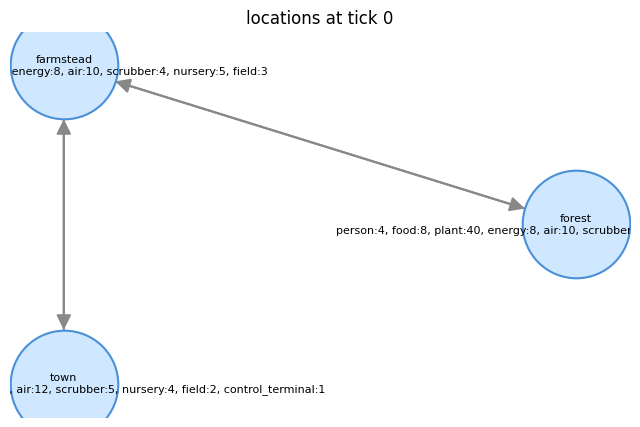

In [10]:
world = initial_world(scenario, seed=0)
viz.draw_world(world, scenario, title="locations at tick 0");

## 6. Transport is just a transform

`haul_cityward` pulls wood one hop along the `cityward` tag each turn;
`haul_food_forestward` pulls food the other way along the *same roads*, because
the reverse edges carry the opposite tag. Neither is a special mechanic — both
are ordinary transforms whose input set happens to be a direction.

In [11]:
w = initial_world(scenario, seed=0)
wood, food = scenario.resource_index["wood"], scenario.resource_index["food"]
print("        " + "".join(f"{lid:>22}" for lid in scenario.location_ids))
for t in range(6):
    cells = "".join(
        f"{f'wood {int(w.stock[l, wood])}, food {int(w.stock[l, food])}':>22}"
        for l in range(scenario.L))
    print(f"tick {t}  {cells}")
    w, _ = run_turn(w, scenario)

                        forest             farmstead                  town
tick 0          wood 0, food 8        wood 0, food 8       wood 0, food 10
tick 1          wood 2, food 7       wood 0, food 14        wood 0, food 4
tick 2         wood 2, food 15       wood 2, food 10        wood 0, food 6
tick 3         wood 2, food 21        wood 2, food 9        wood 2, food 7
tick 4         wood 2, food 24       wood 2, food 12        wood 4, food 9
tick 5         wood 2, food 28       wood 2, food 14       wood 6, food 11


## 7. The world changes its own mind

Nobody submits an order below. The forest preaches a `back_to_the_land`
movement, it ships downstream one hop per turn, and `agitate` spends it to nudge
`farming` up and `logging` down — deltas that superpose and persist. Watch the
town's stack reorder itself.

In [12]:
w = initial_world(scenario, seed=0)
town = scenario.location_index["town"]
farming = scenario.transform_names.index("farming")
logging_ = scenario.transform_names.index("logging")

print("tick   farming   logging   top of town's stack")
for t in range(9):
    print(f"{t:<6} {int(w.priority[town, farming]):+7d} {int(w.priority[town, logging_]):+9d}"
          f"   {scenario.transform_names[w.order(town)[0]]}")
    w, _ = run_turn(w, scenario)

tick   farming   logging   top of town's stack
0           +0        +0   staff_control_terminal
1           +0        +0   staff_control_terminal
2           +0        +0   staff_control_terminal
3           +0        +0   staff_control_terminal
4           +1        -1   farming
5           +2        -2   farming
6           +3        -3   farming
7           +4        -4   farming
8           +5        -5   farming


## 8. Spending a nudge yourself

Your turn is as large as the capacity you built: `staff_control_terminal` mints
one `nudge` per turn, and each point of priority movement costs one. Unspent
nudges decay like any other resource, so political capital is use-it-or-lose-it.

In [ ]:
w = initial_world(scenario, seed=0)
for _ in range(3):
    w, _ = run_turn(w, scenario)

nudge = scenario.resource_index["nudge"]
ws = scenario.transform_names.index("wood_storage")
print(f"town holds {int(w.stock[town, nudge])} nudge(s), "
      f"wood_storage priority {int(w.priority[town, ws]):+d}")

after, _ = run_turn(w, scenario, orders=[SpendNudges("town", {"wood_storage": +1})])
print(f"after spending 1: wood_storage priority {int(after.priority[town, ws]):+d}")

try:
    run_turn(w, scenario, orders=[SpendNudges("town", {"wood_storage": +5})])
except ValueError as e:
    print(f"overspending is rejected: {e}")

## 9. The minimal scenario, for contrast

`simple-world` has no tags, no terminals and no actions — every transform draws
from `local` + `nearby`, which is exactly the pre-tag behaviour. It also still
collapses (issue #1), which the summary's warnings and the observed table make
visible.

In [ ]:
simple = load_scenario(DATA / "simple-world.json")
simple_runtime = analysis.run_and_observe(simple, ticks=8)
display(Markdown(analysis.observed_summary(simple, simple_runtime)))
dagviz.show(simple, runtime=simple_runtime, title="simple-world")